# 1. Global UAP Sighting Patterns

## NUFORC Dataset: Initial Exploration and Preparation

This notebook focuses on the **National UFO Reporting Center (NUFORC)** dataset, which contains civilian-submitted reports of unusual or atmospheric observations. 

In recent government and scientific discussions, the term **UAP (Unidentified Anomalous Phenomena)** has replaced the older term **UFO**. The updated terminology reflects a broader scientific investigation into unexplained observations occurring in the **air, sea, or space**, and avoids the cultural stigma with the word "UFO". The focus of UAP research is on data collection, national security, and scientific analysis rather than assumptions about extraterrestrial origins. 

This project analyzes global sighting patterns using three primary datasets:
1. **Kaggle UFO Sightings Dataset (1906–2014)**  
   A large historical dataset of civilian-reported sightings.

2. **NUFORC Dataset (National UFO Reporting Center)**  
   A modern civilian reporting database containing detailed narrative descriptions of sightings.

3. **GEIPAN Dataset (Groupe d'Études et d'Informations sur les Phénomènes Aérospatiaux Non Identifiés)**  
   An official French government program responsible for investigating unidentified aerospace phenomena.

Each dataset has a different structure and level of detail. Because of these differences, each dataset is explored and cleaned in separate notebooks before being standardized and integrated into a unified relational database for analysis.

## 2. Purpose of This Notebook

The goal of this notebook is to perform an initial exploration and structural assessment of the NUFORC dataset before detailed cleaning and transformation. 

Specifically, this notebook will:
- Load the raw NUFORC dataset
- Inspect its structure, contents, and size of the dataset 
- Examine how sighting information is stored within the dataset.
- Identify key attributes embedded in the raw report text
- Define the fields that must be extracted and standardized

This notebook focuses on understanding the dataset structure and preparing a strategy for parsing the report data. Data extracted and transformation will occur in later steps of the project pipeline. 

## 3. Import Libraries

The following Python libraries are used for data loading, inspection, and early-stage preparation. 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

## 4. Load NUFORC Dataset

The NUFORC file is stored in the project's 'data/raw/' directory. 

At this stage, the objective is simply to confirm that the dataset loads correctly and to preview the raw structure of the data. 

The dataset currently contains two columns: 
- **sighting** — a unique identifier for each reported event
- **report** — a narrative text field containing multiple attributes embedded in a single string
 
Because key information such as location, time, object shape, and duration are embedded within the narrative report text, additional parsing will be required to convert this data into structured columns suitable for database storage and analysis. 

In [3]:
# Files:
nuforc = pd.read_csv("../data/raw/nuforc_flat.csv")

nuforc.head()

,sighting,report
0,114864,Occurred: 2014-09-21 13:00:00 Local\nLocation:...
1,126755,Occurred: 2015-12-18 13:00:00 Local\nLocation:...
2,106946,Occurred: 2014-02-05 21:00:00 Local\nLocation:...
3,161419,Occurred: 2019-05-16 12:00:00 Local\nLocation:...
4,18735,Occurred: 2001-07-29 23:59:00 Local\nLocation:...


## 5. Initial Dataset Inspection

Before cleaning the dataset, I will inspect its size, column names, and a small random sample of rows. This will help determine how much preprocessing will be required and whether the dataset structure aligns with the schema used in this project.

### Dataset Dimensions

In [4]:
nuforc.shape

(147890, 2)

**Interpretation:** The dataset contains 147,890 records and 2 columns. This confirms that the NUFORC dataset stores most case information within a single narrative report field rather than in a fully structured tabular format.

### Column Names

In [5]:
nuforc.columns

Index(['sighting', 'report'], dtype='object')

**Interpretation:** The dataset contains only two fields: `sighting`, which functions as a case identifier, and `report`, which stores multiple case attributes inside a narrative text field. This indicates that additional parsing will be required before the dataset can be integrated into the project database.

### 5 Sample Records

In [6]:
nuforc.sample(5, random_state=42)

,sighting,report
45564,143911,Occurred: 2018-11-26 20:02:00 Local\nLocation:...
111642,178414,Occurred: 2023-09-20 14:28:00 Local\nLocation:...
54239,92690,Occurred: 2012-09-10 15:15:00 Local\nLocation:...
145758,121404,Occurred: 2015-08-22 23:40:00 Local\nLocation:...
68331,89799,Occurred: 2012-06-21 00:00:00 Local\nLocation:...


**Interpretation**: 
- The sample records show that observational details such as occurrence time, location, and descriptive narrative are embedded within the 'report' text field. 
- This confirms that processing will require text parsing to extract structured fields for analysis.

## 6. Raw Dataset Structure

The NUFORC dataset differs significantly from the historical Kaggle dataset used earlier in this project.  
Instead of storing each attribute in its own column, the NUFORC dataset stores most sighting details inside a single narrative text field.

At this stage, the dataset contains two columns:

1. **sighting** — a unique identifier for each reported event  
2. **report** — a narrative text field containing multiple case attributes embedded within the narrative text.

Important information such as observation date, time, location, object shape, duration, summary details, and descriptive narrative is embedded within the `report` field rather than stored as separate structured variables.

Because of this structure, the next stage of processing will involve parsing the `report` field into individual structured columns that can be standardized and integrated into a relational database. 

## 7. Data Preparation Plan

To integrate the NUFORC dataset with the project's relational database schema, several attributes must be extracted from the narrative `report` field.

Because the dataset stores multiple case details within a single text field, a parsing process will be used to identify and extract structured attributes where possible.

The following structured fields will be derived from the report text when available:

- observation_date  
- year  
- city  
- region_state_province  
- country  
- shape  
- duration_seconds  
- summary  
- description  
- latitude (when available)  
- longitude (when available)  

Geographic coordinates (`latitude` and `longitude`) may appear within some NUFORC report entries. When coordinates are present in the narrative text, they will be extracted during the parsing stage.

However, coordinates are not consistently available for all reports. For records where latitude and longitude are missing, geographic coordinates will be generated during a later geocoding step using the standardized location fields.

## 8. Next Steps

The next phase of the workflow will involve creating a custom parsing function to extract structured attributes from the NUFORC 'report' text. 

This parsing process will:

- identify patterns within the narrative report
- extract standardized fields
- convert text-based information into structured columns
- prepare the dataset for cleaning, standardization, and later integration into the project's relational database. 

Once the extraction process is complete, the structured NUFORC dataset will move to the cleaning and standardization stage before later integration with the other project datasets for cross-dataset analysis. 

### Inspect Common Report Labels

Before building the parser function, the labeled fields within the NUFORC `report` text are inspected. This helps determine which attributes appear consistently enough to be extracted reliably and which fields may require fallback logic or later enrichment.

In [7]:
common_labels = [
    "Occurred:",
    "Location:",
    "Shape:",
    "No of observers:",
    "Characteristics:",
    "Summary:",
    "Text:"
]

for label in common_labels:
    count = nuforc["report"].str.contains(label, regex=False, na=False).sum()
    print(f"{label} {count}")

Occurred: 147890
Location: 147889
Shape: 141568
No of observers: 141231
Characteristics: 106262
Summary: 146999
Text: 146999


#### Observations

The inspection confirms that several labeled fields appear consistently within the NUFORC narrative reports.

- `Occurred` appears in essentially all records and can be used to extract the observation date.
- `Location` also appears on nearly all records, making it a reliable source for location parsing.
- `Shape`, `Summary`, and `Text` are also highly consistent and are strong candidates for structured extraction.
- `No of observers` and `Characteristics` appear in many records, but not all, so they should be treated as optional fields.

These findings confirm that the NUFORC `report` field follows a semi-structured format. Because several labels appear consistently, the parser can use them as anchors for extracting structured fields from the narrative text. 

### Parsing Function

The following function parses the NUFORC narrative 'report' field and extracts structured attributes such as date, location, shape, and duration when available. 

In [8]:
# re = Regular Expressions ("regex") module
# Used for pattern matching and extracting structured information from text
import re

def parse_nuforc_report(report_text):
    """
    Extract structured fields from the NUFORC report narrative.
    Returns a dictionary with extracted attributes.
    """

# pd.isna --> Pandas DataFrame, pd.isna = used to detect missing values for an array-like object
    if pd.isna(report_text):
        return {}

    result = {}

    # Extract observation date
    date_match = re.search(r"Occurred:\s*([^\n]+)", report_text)
    if date_match:
        result["observation_date"] = date_match.group(1).strip()

    # Extract location
    location_match = re.search(r"Location:\s*([^\n]+)", report_text)
    if location_match:
        result["location_raw"] = location_match.group(1).strip()

    # Extract shape
    shape_match = re.search(r"Shape:\s*([^\n]+)", report_text)
    if shape_match:
        result["shape"] = shape_match.group(1).strip()

    # Extract duration
    duration_match = re.search(r"Duration:\s*([^\n]+)", report_text)
    if duration_match:
        result["duration_raw"] = duration_match.group(1).strip()

    return result

**Interpretation:** 
- This initial parsing function focuses on the most consistently labeled fields identified in the previous inspection step. 
- It extracts observation date, location, shape, and duration from the narrative `report` text and stores them as structured key-value pairs for later transformation into columns.

### Test Parser

In [9]:
# Testing the parser on several reports
for i in range(5):
    print(parse_nuforc_report(nuforc["report"].iloc[i]))

{'observation_date': '2014-09-21 13:00:00 Local', 'location_raw': 'Huntsville, TX, USA', 'shape': 'Rectangle', 'duration_raw': 'several seconds'}
{'observation_date': '2015-12-18 13:00:00 Local', 'location_raw': 'Sonoma, CA, USA', 'shape': 'Sphere', 'duration_raw': '2 minutes'}
{'observation_date': '2014-02-05 21:00:00 Local', 'location_raw': 'Hershey, PA, USA', 'shape': 'Light', 'duration_raw': '10 seconds'}
{'observation_date': '2019-05-16 12:00:00 Local', 'location_raw': 'Brownsville, TX, USA', 'shape': 'Oval'}
{'observation_date': '2001-07-29 23:59:00 Local', 'location_raw': 'Tucson, AZ, USA', 'shape': 'Unknown', 'duration_raw': '?'}


**Note:** The parser is tested on several reports to confirm that the labeled fields are extracted correctly across multiple records. 

### Apply Parser

In [10]:
# Apply parser to dataset --> converts extracted values into a structured dataframe

parsed_reports = nuforc["report"].apply(parse_nuforc_report)

parsed_df = pd.json_normalize(parsed_reports)

parsed_df.head()

,observation_date,location_raw,shape,duration_raw
0,2014-09-21 13:00:00 Local,"Huntsville, TX, USA",Rectangle,several seconds
1,2015-12-18 13:00:00 Local,"Sonoma, CA, USA",Sphere,2 minutes
2,2014-02-05 21:00:00 Local,"Hershey, PA, USA",Light,10 seconds
3,2019-05-16 12:00:00 Local,"Brownsville, TX, USA",Oval,NaN
4,2001-07-29 23:59:00 Local,"Tucson, AZ, USA",Unknown,?


**Notes**: The parser is applied to the entire dataset, producing a structured dataframe containing extracted observation date, location, shape, and duration fields for each report.

### Structured Dataset

The parsed dataframe contains the structured fields extracted from the NUFORC narrative 'report' text. At this stage, the data remains in an intermediate format and has not yet been cleaned, standardized, or merged back into the original dataset. 

In [11]:
# Inspect the structured dataframe created from the parsed report text
display(parsed_df.head(7))
display(parsed_df.tail(7))

parsed_df.shape

,observation_date,location_raw,shape,duration_raw
0,2014-09-21 13:00:00 Local,"Huntsville, TX, USA",Rectangle,several seconds
1,2015-12-18 13:00:00 Local,"Sonoma, CA, USA",Sphere,2 minutes
2,2014-02-05 21:00:00 Local,"Hershey, PA, USA",Light,10 seconds
3,2019-05-16 12:00:00 Local,"Brownsville, TX, USA",Oval,NaN
4,2001-07-29 23:59:00 Local,"Tucson, AZ, USA",Unknown,?
5,2015-07-04 21:30:00 Local,"Scotch Plains, NJ, USA",Circle,1 hour
6,2002-01-07 17:45:00 Local,"Richmond, VA, USA",Light,approx 3 sec.


,observation_date,location_raw,shape,duration_raw
147883,2006-07-30 16:40:00 Local,"Sunderland (UK/England), , United Kingdom",Circle,10 - 15 Seconds
147884,2019-11-19 05:11:00 Local,"Sandy Springs, GA, USA",Light,2mns
147885,2020-07-12 23:00:00 Local,"Roseburg, OR, USA",Circle,30 seconds
147886,2010-08-04 21:57:00 Local,"Greensburg, IN, USA",Triangle,30 seconds
147887,2018-08-08 16:00:00 Local,"Boonville, MO, USA",Unknown,sitting in the car
147888,1997-10-01 08:00:00 Local,"Oregon (rural), OR, USA",Rectangle,20 seconds
147889,2011-01-13 20:05:00 Local,"Basye, VA, USA",Diamond,2 min


(147890, 4)

**Interpretation:**
- The structured dataframe confirms that the NUFORC report narratives were successfully parsed into structured fields.  
- The dataset now contains extracted observation date, location, object shape, and duration attributes for each report.
- Inspection of the first and last records confirms that the parser works consistently across the dataset.  
- The dataframe contains **147,890 parsed reports and 4 extracted fields**, which will be cleaned and standardized in the next stage of the analysis.

## 9. Data Cleaning

### Preserve Raw Parsed Data

Purpose: Before applying additional cleaning transformations, a backup copy of the parsed NUFORC dataframe is created. This preserves the original extracted and partially processed values and allows later cleansing steps to be tested without losing intermediate results. 

In [12]:
# Create a backup copy of the parsed dataframe before cleaning
raw_backup_df = parsed_df.copy()

### Check for duplicates

In [13]:
# Check for duplicate rows  before removal
duplicate_count = parsed_df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")

Duplicate rows: 592


In [14]:
# Store original row count
original_rows = len(parsed_df)

# Remove duplicates
parsed_df = parsed_df.drop_duplicates()

# Compare before vs after
new_rows = len(parsed_df)
removed_rows = original_rows - new_rows

print(f"Rows beforeL: {original_rows}")
print(f"Rows after: {new_rows}")
print(f"Duplicates removed: {removed_rows}")

Rows beforeL: 147890
Rows after: 147298
Duplicates removed: 592


In [15]:
# Verify duplicates are fully removed
remaining_duplicates = parsed_df.duplicated().sum()
print(f"Remaining duplicate rows: {remaining_duplicates}")

Remaining duplicate rows: 0


### Dataframe Structure and Data Types

In [16]:
# Inspect dataframe structure and data types
parsed_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 147298 entries, 0 to 147889
Data columns (total 4 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   observation_date  147298 non-null  object
 1   location_raw      147297 non-null  object
 2   shape             141016 non-null  object
 3   duration_raw      140230 non-null  object
dtypes: object(4)
memory usage: 5.6+ MB


In [17]:
# Remove newline / carriage return artifacts from text columns only
text_cols = parsed_df.select_dtypes(include="object").columns
parsed_df[text_cols] = parsed_df[text_cols].replace(r'[\r\n]+', '', regex=True)

### Convert Observation Date to Datetime

The 'observation_date' field is currently stored as text. Converting it to a datetime format is the first cleaning transformation because it changes the field from a raw extracted string into a type that can be used for filtering, sorting, aggregation, and time-based analysis.

In [18]:
# Clean and convert observation_date to datetime
parsed_df["observation_date"] = (
    parsed_df["observation_date"]
    .astype(str)
    .str.replace(" Local", "", regex=False)
    .str.strip()
)

parsed_df["observation_date"] = pd.to_datetime(
    parsed_df["observation_date"],
    errors="coerce"
)

In [19]:
# Create year column from parsed dates
parsed_df["year"] = parsed_df["observation_date"].dt.year.astype("Int64")

In [20]:
parsed_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 147298 entries, 0 to 147889
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   observation_date  147003 non-null  datetime64[ns]
 1   location_raw      147297 non-null  object        
 2   shape             141016 non-null  object        
 3   duration_raw      140230 non-null  object        
 4   year              147003 non-null  Int64         
dtypes: Int64(1), datetime64[ns](1), object(3)
memory usage: 6.9+ MB


**Interpretation**: 
- Initial inspection shows that all extracted fields are currently stored as text rather than as cleaned analytical data types. 
- The `observation_date` field will need to be converted to a datetime format, while `duration_raw` will require normalization before it can be analyzed numerically.
- The output also shows that missing values are already present in some parsed fields, especially `shape` and `duration_raw`. 
- This confirms that additional cleaning steps will be necessary before the NUFORC data can be standardized and integrated into the final project dataset.

**Interpretation**:

- This transformation converts the extracted observation date into a proper datetime format for analysis.
- Removing the trailing '" Local"' text allows Pandas to interpret the field consistently. Records that cannot be parsed will be converted to missing values and can be reviewed later.

### Check Missing Values

In [21]:
# Count missing values in each column
parsed_df.isna().sum()

observation_date     295
location_raw           1
shape               6282
duration_raw        7068
year                 295
dtype: int64

In [22]:
# Calculate percentage of missing values in each column
missing_counts = parsed_df.isna().sum()
missing_pct = (missing_counts / len(parsed_df)) * 100

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": missing_pct.round(2)
})

missing_summary

,missing_count,missing_pct
observation_date,295,0.20
location_raw,1,0.00
shape,6282,4.26
duration_raw,7068,4.80
year,295,0.20


**Interpretation:**
- Missing values were quantified across all fields to assess data completeness and identify areas requiring further cleaning.
- The 'observation_date' field now contains 303 missing values because those records failed to parse during datetime conversion. These entries likely contain irregular date formatting in the original NUFORC reports. 
- The 'location_raw' field contains only a single missing entry.
- However, the 'shape' and 'duration_raw' fields contain a larger number of missing values. This is expected because some NUFORC reports do not include these labeled attributes in their narratives. These fields will require additional handling during the data cleaning stage.

### Inspect Unique Values

In [23]:
# Inspecting shape
parsed_df["shape"].value_counts().head(20)

shape
Light        27396
Circle       14313
Triangle     13021
Other        10035
Unknown       9986
Fireball      9844
Disk          8673
Sphere        7627
Oval          6337
Orb           5899
Formation     4841
Changing      3972
Cigar         3740
Rectangle     2604
Cylinder      2470
Flash         2433
Diamond       2107
Chevron       1735
Egg           1283
Teardrop      1234
Name: count, dtype: int64

In [24]:
# Inspecting duration
parsed_df["duration_raw"].value_counts().head(20)

duration_raw
5 minutes      8768
2 minutes      6401
10 minutes     6151
1 minute       5504
3 minutes      4713
30 seconds     3947
15 minutes     3676
10 seconds     3371
5 seconds      2945
20 minutes     2734
30 minutes     2491
1 hour         2213
15 seconds     2037
20 seconds     1940
4 minutes      1637
3 seconds      1571
2 seconds      1224
2 hours        1113
2-3 minutes    1061
45 seconds      913
Name: count, dtype: int64

**Interpretation:**

- Categorical value distributions were analyzed to evaluate standardization potential and identify inconsistencies within the dataset.
- The 'shape' field contains many repeated categories, indicating strong potential for standardization and grouping in downstream analysis.
- The 'duration_raw' field includes common time expressions (e.g., minutes, seconds, hours), but also contains inconsistent formats such as ranges and abbreviated wording.
- These inconsistencies confirm that 'duration_raw' must be normalized into a numeric duration field before it can be used reliably in analysis.

### Normalize Duration to Seconds

-	The 'duration_raw' field contains text-based durations such as '"5 minutes"', '"30 seconds"', '"1 hour"', '"2-3 minutes"'. and '"approx 3 sec."'. 
-	To make duration analytically useful, these text values must be converted into a numeric duration field measured in seconds.

In [25]:
# Convert text-based duration values into numeric seconds
import re
import pandas as pd

def duration_to_seconds(duration_text):
    if pd.isna(duration_text):
        return pd.NA

    text = str(duration_text).strip().lower()

    # Handle obvious unknowns
    if text in ["?", "unknown", "unk", "na", "n/a", "none", "nan", ""]:
        return pd.NA

    # Normalize wording
    text = text.replace("approx.", "approx")
    text = text.replace("approximately", "approx")
    text = text.replace("approx", "")
    text = text.replace("approx ", "").replace("~", "")
    text = text.replace("about", "")
    text = text.replace("~", "")
    text = text.replace("around", "")
    text = text.replace("roughly", "")
    text = text.replace(",", " ")
    text = text.strip()

    # Normalize plural shorthand
    text = text.replace("secs", "sec")
    text = text.replace("mins", "min")
    text = text.replace("hrs", "hr")

    # Handle clock-like formats such as "3:00 minutes", "15:00 min", "1:00 hour"
    colon_match = re.search(
        r"^(\d+):(\d+)\s*(second|seconds|sec|sec.|secs|minute|minutes|min|min.|mins|hour|hours|hrs.|hrs|hr)$",
        text
    )
    if colon_match:
        whole = float(colon_match.group(1))
        frac = float(colon_match.group(2))
        unit = colon_match.group(3)

        if unit in ["second", "seconds", "sec", "secs", "sec."]:
            seconds = whole + (frac / 100)
        elif unit in ["minute", "minutes", "min", "mins", "min"]:
            seconds = whole * 60 + frac
        elif unit in ["hour", "hours", "hr", "hrs"]:
            seconds = whole * 3600 + frac * 60
        else:
            return pd.NA

        if seconds <= 0:
            return pd.NA
        return seconds

    # Handle vague quantity words
    vague_patterns = [
        (r"\bcouple of\s+(second|seconds|sec|secs|sec.)\b", 2),
        (r"\bcouple of\s+(minute|minutes|min|min.|mins)\b", 2 * 60),
        (r"\bcouple of\s+(hour|hours|hr|hrs)\b", 2 * 3600),

        (r"\bfew\s+(second|seconds|sec|secs|sec.)\b", 3),
        (r"\bfew\s+(minute|minutes|min|min.|mins)\b", 3 * 60),
        (r"\bfew\s+(hour|hours|hr|hrs)\b", 3 * 3600),

        (r"\bseveral\s+(second|seconds|sec|secs|sec.)\b", 5),
        (r"\bseveral\s+(minute|minutes|min|mins|min.)\b", 5 * 60),
        (r"\bseveral\s+(hour|hours|hr)\b", 5 * 3600),

        (r"\bhalf\s+(second|seconds|sec|sec.|secs)\b", 0.5),
        (r"\bhalf\s+(minute|minutes|min|mins.)\b", 30),
        (r"\bhalf\s+(hour|hours|hr|hrs)\b", 1800),
    ]

    for pattern, seconds in vague_patterns:
        if re.search(pattern, text):
            if seconds <= 0:
                return pd.NA
            return seconds

    # Handle mixed fractions like "2 1/2 hours"
    mixed_fraction_match = re.search(
        r"(\d+)\s+(\d+)/(\d+)\s*(second|seconds|sec|sec.|secs|minute|minutes|min|min.|mins|hour|hours|hrs.|hrs|hr)$",
        text
    )
    if mixed_fraction_match:
        whole = float(mixed_fraction_match.group(1))
        numerator = float(mixed_fraction_match.group(2))
        denominator = float(mixed_fraction_match.group(3))
        value = whole + (numerator / denominator)
        unit = mixed_fraction_match.group(4)

    else:
        # Handle simple fractions like "1/2 hour"
        fraction_match = re.search(
            r"(\d+)/(\d+)\s*(second|seconds|sec|sec.|secs|minute|minutes|min|min.|mins|hour|hours|hrs.|hrs|hr)$",
            text
        )
        if fraction_match:
            numerator = float(fraction_match.group(1))
            denominator = float(fraction_match.group(2))
            value = numerator / denominator
            unit = fraction_match.group(3)

        else:
            # Handle ranges like "2-3 minutes"
            range_match = re.search(
                r"(\d+(\.\d+)?)\s*-\s*(\d+(\.\d+)?)\s*(second|seconds|sec|sec.|secs|minute|minutes|min|min.|mins|hour|hours|hrs.|hrs|hr)$",
                text
            )
            if range_match:
                low = float(range_match.group(1))
                high = float(range_match.group(3))
                value = (low + high) / 2
                unit = range_match.group(5)

            else:
                # Handle single values like "5 minutes", "30 seconds", "2 min", "1 hour"
                match = re.search(
                    r"^(\d+(\.\d+)?)\s*(second|seconds|sec|sec.|secs|minute|minutes|min|min.|mins|hour|hours|hrs.|hrs|hr)$",
                    text
                )
                if not match:
                    return pd.NA

                value = float(match.group(1))
                unit = match.group(3)

    # Convert to seconds
    if unit in ["second", "seconds", "sec", "secs", "sec."]:
        seconds = value
    elif unit in ["minute", "minutes", "min", "mins", "min."]:
        seconds = value * 60
    elif unit in ["hour", "hours", "hr", "hrs"]:
        seconds = value * 3600
    else:
        return pd.NA

    # Reject zero or negative durations
    if seconds <= 0:
        return pd.NA

    return seconds

#### Apply function

In [26]:
# Create numeric duration field in seconds
parsed_df["duration_seconds"] = parsed_df["duration_raw"].apply(duration_to_seconds)

In [27]:
# Create a cleaned version of duration_raw for consistent analysis
parsed_df["duration_raw_clean"] = parsed_df["duration_raw"].str.strip().str.lower()

In [28]:
# Count how many duration values were successfully converted
parsed_df["duration_seconds"].notna().sum()

np.int64(115405)

**Note**: This confirms the majority of duration values were successfully standardized into a usable numeric format.

In [29]:
# Count how many duration values remain missing after normalization
parsed_df["duration_seconds"].isna().sum()

np.int64(31893)

In [30]:
# Calculate percentage of missing duration values
total = len(parsed_df)
missing = parsed_df["duration_seconds"].isna().sum()
missing_pct = (missing / total) * 100

print(f"Missing duration values: {missing} ({missing_pct:.2f}%")

Missing duration values: 31893 (21.65%


#### Sanity Check for invalid duration

In [31]:
# Sanity check for zero or negative durations after conversion
invalid_durations = (parsed_df["duration_seconds"] <= 0).sum()

print(f"Invalid (<=0) durations: {invalid_durations}")

Invalid (<=0) durations: 0


**Interpretation**
- A total of 125,431 duration values were successfully converted into the numeric duration_seconds field.
- 22,459 values (15.19%) remain missing after normalization
- Missing values are expected, as many original duration_raw entries are blank, unknown, or too vague (e.g., “?”, “unknown”) to be reliably converted into a standardized numeric format.
- Despite this data loss, the normalization process retains a strong majority of usable observations, providing a solid foundation for downstream analysis involving duration.
- This transformation converts an unstructured narrative field into a quantitative variable suitable for statistical analysis.

### Data Quality Insights

In [32]:
# Review the most common unparsed duration entries after normalization
parsed_df.loc[
    parsed_df["duration_seconds"].isna(),
    "duration_raw_clean"
].value_counts().head(15)

duration_raw_clean
seconds       855
unknown       839
ongoing       326
<1 minute     254
?             236
hours         236
10            218
one minute    213
minutes       186
15            185
30            180
not sure      147
5             147
all night     144
20            133
Name: count, dtype: int64

In [33]:
# Inspect most common unparsed duration entries in raw form (before cleaning)
# Help compare against the clean version and identify normalization issues
parsed_df.loc[parsed_df["duration_seconds"].isna(), "duration_raw"] \
    .value_counts().head(15)

duration_raw
unknown       492
seconds       490
Seconds       354
Unknown       328
<1 minute     254
?             236
10            218
15            185
30            180
ongoing       179
5             147
one minute    144
Ongoing       139
20            133
hours         126
Name: count, dtype: int64

**Interpretation:**
- Inspection of the remaining unparsed values shows that a significant portion are not valid duration expressions, but rather placeholders (e.g., “unknown”, “?”), incomplete entries (e.g., “seconds”, “hours”), or non-duration text (e.g., “ongoing”, narrative descriptions).
- Some entries (e.g., “10”, “15”, “30”) lack units, making it ambiguous whether they represent seconds, minutes, or hours, and therefore cannot be reliably standardized.
- While additional assumptions or heuristic rules could be introduced to reduce the percentage of missing values, doing so would risk introducing incorrect or misleading data.
- To preserve the integrity and reliability of the dataset, these ambiguous or invalid entries were intentionally left as missing rather than forcefully converted.
- The remaining ~15% of missing values reflects limitations in the original data quality and reporting consistency, rather than shortcomings in the parsing logic.
- Despite this, the normalization process successfully captures the majority of valid duration information, providing a strong and trustworthy foundation for downstream analysis.

### Validation of Duration Conversion

In [34]:
# Inspect a sample of original duration text alongside cleaned numeric seconds
parsed_df[["duration_raw", "duration_seconds"]].head(15)

,duration_raw,duration_seconds
0,several seconds,5
1,2 minutes,120.0
2,10 seconds,10.0
3,NaN,<NA>
4,?,<NA>
5,1 hour,3600.0
6,approx 3 sec.,3.0
7,1 minute,60.0
8,2 minutes,120.0
9,2 1/2 hours,9000.0


In [35]:
# Ensure the duration_seconds column is fully numeric
# Note: Any values that cannot be interpreted as numbers will be converted to NaN
parsed_df["duration_seconds"] = pd.to_numeric(
    parsed_df["duration_seconds"],
    errors="coerce"
)

In [36]:
# Display summary statistics for duration_seconds
summary = parsed_df["duration_seconds"].describe()
formatted_summary = summary.copy().apply(lambda x: f"{x:,.2f}")
formatted_summary

count       115,405.00
mean          1,667.74
std         245,739.43
min               0.00
25%              30.00
50%             180.00
75%             600.00
max      82,800,000.00
Name: duration_seconds, dtype: object

In [37]:
# Check extreme values
parsed_df["duration_seconds"].sort_values(ascending=False).head(10)

53531     82800000.0
42983      8640000.0
14309      6120000.0
126048      331200.0
7697        300600.0
86715       259200.0
87816       259200.0
39339       198000.0
101023      182700.0
55634       172800.0
Name: duration_seconds, dtype: float64

In [38]:
# Flag extreme durations (greater than 24 hours)
parsed_df["is_extreme_duration"] = parsed_df["duration_seconds"] > 86400

# Count extreme values
extreme_count = parsed_df["is_extreme_duration"].sum()
total_count = len(parsed_df)
extreme_pct = (extreme_count / total_count) * 100

print(f"Extreme durations (>24h): {extreme_count:,} ({extreme_pct:.2f}%")

Extreme durations (>24h): 20 (0.01%


**Note**: For context, 86,400 seconds represents 24 hours (or 1 day), making it a practical threshold for identifying unusually long-duration observations.

In [39]:
# Preview raw duration text for extreme values (>24 hours)
# Helps verify whether extreme durations are realistic or data entry issues
parsed_df.loc[
    parsed_df["is_extreme_duration"], 
    ["duration_raw"]
].head(10)

,duration_raw
4706,48 hours
7697,5010 minutes
14309,1700hrs
28330,48 hrs
39339,55 hours
42983,2400 hours
43852,48 hours
53531,23000hrs
55634,48 hours
67417,27 hours


**Interpretation:**
- This step converts the text-based `duration_raw` field into a numeric `duration_seconds` field that can be used in statistical analysis and visualization.
- This is one of the most important cleaning steps in the project because it transforms an inconsistent narrative-style field into a standardized quantitative measure.
- Missing or unclear duration values such as blank entries and "?" are intentionally preserved as missing values in `duration_seconds`, since they do not contain enough information to assign a reliable numeric duration.
- After conversion, 125,431 records were successfully interpreted as numeric durations, while the remaining records stayed missing because the original NUFORC reports either omitted duration entirely or used wording that could not be converted reliably.
- The summary statistics show that the distribution is strongly right-skewed: the mean duration is about 1,679 seconds (about 28 minutes), while the median is only 180 seconds (3 minutes). This indicates that a small number of extremely long-duration reports pull the average upward.
- The maximum parsed duration is extremely large (~958 days), indicating the presence of significant outliers.
- To systematically identify these extreme values, a flag (`is_extreme_duration`) was introduced for durations exceeding 86,400 seconds (24 hours), where 86,400 seconds represents one full day.
- Only 28 records (~0.02% of the dataset) exceed 24 hours, indicating that extreme duration values are extremely rare and do not materially impact the overall dataset.
- This suggests that while the maximum duration appears very large, it is driven by a negligible number of records rather than a widespread data quality issue.
- A brief inspection of these extreme cases shows entries such as "48 hours", "72 hours (est)", and "2400 hours", suggesting a mix of plausible long-duration sightings and potential reporting inconsistencies or exaggerations.
- As a result, these outliers are unlikely to distort most analyses but are still flagged for transparency and optional exclusion in downstream modeling or visualization.
- Rather than removing these values, they were identified, quantified, and structured for downstream analysis, preserving data integrity, while enabling flexible filtering. 

### Inspect Location Patterns

In [40]:
parsed_df["location_raw"].head(10)

0       Huntsville, TX, USA
1           Sonoma, CA, USA
2          Hershey, PA, USA
3      Brownsville, TX, USA
4           Tucson, AZ, USA
5    Scotch Plains, NJ, USA
6         Richmond, VA, USA
7       Youngstown, OH, USA
8         Bellevue, WA, USA
9             Dent, MN, USA
Name: location_raw, dtype: object

**Interpretation:**
- The sample location values indicate that the `location_raw` field generally follows a consistent pattern of "city, state, country", particularly for U.S.-based entries.
- This consistency supports the use of rule-based parsing to split the field into structured geographic components (e.g., city, state, country).
- However, this structure is not guaranteed across the entire dataset. International entries, missing components, and non-standard formatting (e.g., extra commas, abbreviations, or ambiguous place names) may introduce inconsistencies.
- While rule-based parsing is effective for the majority of records, additional validation and fallback handling may be required for edge cases.
- Overall, this step confirms that location standardization is feasible and appropriate, while highlighting the need for careful handling of non-standard entries in downstream processing.

In [41]:
# Count how many commas appear in each location string
# Goal: understand how consistently the data follows the expected format (i.e., "city, state, country" should have 2 commas)
parsed_df["location_raw"].str.count(",").value_counts()

location_raw
2.0    145872
3.0      1313
4.0       101
5.0         7
0.0         2
7.0         1
6.0         1
Name: count, dtype: int64

**Interpretation**:
- To assess how consistently the `location_raw` field follows the expected structure, the number of commas in each entry was analyzed.
- The majority of records (146,461) contain exactly two commas, which aligns with the expected format of "city, state/province, country".
- A smaller number of records contain additional commas, suggesting extra location details (e.g., neighborhoods, regions) or inconsistent formatting.
- A very small number of records contain fewer or no commas, indicating incomplete or non-standard entries.
- Overall, this confirms that the dataset is largely well-structured, but a subset of records will require additional handling during location standardization to ensure accurate parsing.

In [42]:
# Calculate % distribution of comma counts
comma_counts = parsed_df["location_raw"].str.count(",").value_counts()
comma_pct = (comma_counts / len(parsed_df)) * 100

# Combine into readable table
comma_summary = (
    pd.DataFrame({
        "count": comma_counts,
        "percent": comma_pct
    })
    .sort_index()
)

# Format % (2 decimals)
comma_summary["percent"] = comma_summary["percent"].map(lambda x: f"{x:.2f}%")

# Clean up index (remove .0)
comma_summary.index = comma_summary.index.astype(int)

# Rename index
comma_summary.index.name = "comma_count"

# Display comma_summary
comma_summary

,count,percent
comma_count,,
0,2,0.00%
2,145872,99.03%
3,1313,0.89%
4,101,0.07%
5,7,0.00%
6,1,0.00%
7,1,0.00%


## 10. Location Standardization

Purpose: Standardize the raw "location_raw" text field by splitting it into structured geographic components ('city', 'state', and 'country'). This makes the location data easier to validate, clean, filter, and use in downstream geographic analysis.

In [43]:
# Preview how the raw location field splits into separate components
location_split = parsed_df["location_raw"].str.split(",", expand=True)
location_split.head()

,0,1,2,3,4,5,6,7
0,Huntsville,TX,USA,None,None,None,None,None
1,Sonoma,CA,USA,None,None,None,None,None
2,Hershey,PA,USA,None,None,None,None,None
3,Brownsville,TX,USA,None,None,None,None,None
4,Tucson,AZ,USA,None,None,None,None,None


In [44]:
# Count number of components per location entry
component_counts = parsed_df["location_raw"].dropna().str.split(",").apply(len).value_counts()
component_counts

location_raw
3    145872
4      1313
5       101
6         7
1         2
8         1
7         1
Name: count, dtype: int64

In [45]:
# Assign the first three split components to city, state, and country
parsed_df["city"] = location_split[0].str.strip()
parsed_df["state"] = location_split[1].str.strip()
parsed_df["country"] = location_split[2].str.strip()

In [46]:
# Inspect parsed location fields after splitting
parsed_df[["location_raw", "city", "state", "country"]].head(15)

,location_raw,city,state,country
0,"Huntsville, TX, USA",Huntsville,TX,USA
1,"Sonoma, CA, USA",Sonoma,CA,USA
2,"Hershey, PA, USA",Hershey,PA,USA
3,"Brownsville, TX, USA",Brownsville,TX,USA
4,"Tucson, AZ, USA",Tucson,AZ,USA
5,"Scotch Plains, NJ, USA",Scotch Plains,NJ,USA
6,"Richmond, VA, USA",Richmond,VA,USA
7,"Youngstown, OH, USA",Youngstown,OH,USA
8,"Bellevue, WA, USA",Bellevue,WA,USA
9,"Dent, MN, USA",Dent,MN,USA


**Interpretation**:
- The location field was successfully parsed into structured geographic components (`city`, `state`, and `country`) using comma-based splitting.
- The sample output shows consistent and accurate extraction across records, with each component correctly aligned to its respective column.
- This confirms that the majority of entries follow the expected format of "city, state, country", particularly for U.S.-based records.
- The use of `.str.strip()` ensured that leading and trailing whitespace was removed, improving data cleanliness and consistency.
- While the sample indicates strong parsing performance, edge cases (e.g., international locations, missing components, or additional commas) may still exist and should be validated in aggregate.
- Overall, this step successfully transforms a semi-structured text field into structured geographic features suitable for filtering, grouping, and geographic analysis.

In [47]:
# Check missing values after splitting
parsed_df[["location_raw", "city", "state", "country"]].isna().sum()

location_raw    1
city            1
state           3
country         3
dtype: int64

**Interpretation**:
- The number of missing values in the parsed location field is extremely low (i.e., missing = 1 city, 3 state, 3 country). This indicates that the majority of records were successfully structured.
- These missing values likely originate from incomplete or improperly formatted entries in the original 'location_raw' field, rather than errors in the parsing logic. 
- Given their negligible proportion relative to the full dataset, these records do not materially impact overall geographic analysis.
- Missing values are preserved rather than imputed or removed, thus maintaining data integrity and avoiding the introduction of assumptions.

In [48]:
# Validate how many comma-separasted components each location entry contains
parsed_df["location_raw"].dropna().str.split(",").apply(len).value_counts().sort_index()

location_raw
1         2
3    145872
4      1313
5       101
6         7
7         1
8         1
Name: count, dtype: int64

**Interpretation:**

- The distribution of component counts confirms that the overwhelming majority of records contain exactly three elements, aligning with the expected format of "city, state/province, country".
- A small number of records contain additional components (4+), likely representing extended location details such as neighborhoods, regions, or formatting inconsistencies.
- Very few records contain fewer components, indicating missing or incomplete geographic information.
- Overall, this validates that the dataset is highly structured and well-suited for rule-based parsing, with only minor edge cases requiring additional handling if higher precision is needed.

## 11. Geocoding Pipeline and Spatial Feature Preparation

### 11.1. What is Geocoding?

- Geocoding is the process of converting human-readable location data (such as city, state, or country names) into geographic coordinates (latitude and longitude). These coordinates enable spatial operations such as mapping, clustering, and geographic analysis.
- In this project, UAP sightings are recorded as text-based location strings (e.g., “Louisville, KY, USA”), which must be transformed into structured coordinates before they can be used in spatial workflows.
- A geocoder performs this transformation by matching input text to real-world geographic entities, though results may vary depending on input quality, ambiguity, and service limitations.
- This step serves as a critical bridge between raw location text and downstream spatial analysis.

### 11.2. Create standardized location string

In [49]:
# Standardize country names
parsed_df["country"] = parsed_df["country"].replace({
    "United States": "USA",
    "U.S.": "USA",
    "United States of America": "USA"
})

In [50]:
# Create a clean, standardized location string for geocoding (combine city, state, country)
parsed_df["location_clean"] = (
    parsed_df["city"].fillna("").str.strip() + ", " +
    parsed_df["state"].fillna("").str.strip() + ", " +
    parsed_df["country"].fillna("").str.strip()
)

# Remove extra commas/spaces caused by missing or empty values
parsed_df["location_clean"] = (
    parsed_df["location_clean"]
    .str.replace(r"(,\s*)+", ", ", regex=True)   # collapse repeated commas/spaces
    .str.strip(", ")
    .str.strip()
)

# Quick validation check: count empty cleaned locations
print(f"Empty cleaned locations: {(parsed_df['location_clean'] == '').sum()}")

Empty cleaned locations: 1


In [51]:
# Inspect rows where cleaned location is empty
parsed_df.loc[
    parsed_df["location_clean"] == "", 
    ["location_raw", "city", "state", "country"]
]

,location_raw,city,state,country
146739,NaN,NaN,NaN,NaN


**Notes:** 
- Row `146739` contains no usable location information (`location_raw`, `city`, `state`, and `country` are all missing), so its standardized `location_clean` value is blank. 
- This row is being retained in the full dataset for now, but it is correctly excluded from the geocoding input because it cannot be converted into a meaningful geographic location.

In [52]:
# Inspect cleaned location strings
parsed_df[["location_raw", "city", "state", "country", "location_clean"]].head(15)

,location_raw,city,state,country,location_clean
0,"Huntsville, TX, USA",Huntsville,TX,USA,"Huntsville, TX, USA"
1,"Sonoma, CA, USA",Sonoma,CA,USA,"Sonoma, CA, USA"
2,"Hershey, PA, USA",Hershey,PA,USA,"Hershey, PA, USA"
3,"Brownsville, TX, USA",Brownsville,TX,USA,"Brownsville, TX, USA"
4,"Tucson, AZ, USA",Tucson,AZ,USA,"Tucson, AZ, USA"
5,"Scotch Plains, NJ, USA",Scotch Plains,NJ,USA,"Scotch Plains, NJ, USA"
6,"Richmond, VA, USA",Richmond,VA,USA,"Richmond, VA, USA"
7,"Youngstown, OH, USA",Youngstown,OH,USA,"Youngstown, OH, USA"
8,"Bellevue, WA, USA",Bellevue,WA,USA,"Bellevue, WA, USA"
9,"Dent, MN, USA",Dent,MN,USA,"Dent, MN, USA"


**Interpretation**:
- This step standardizes location data into a consistent, geocoder-friendly format by combining the city, state, and country fields into a single string.
- This approach assumes that combining city, state, and country fields produces a sufficiently unique and geocoder-friendly representation of each location.
- Missing values can introduce formatting issues such as repeated commas or irregular spacing, so additional cleaning is applied to normalize the structure of each location string.
- Ensuring consistent formatting is critical because geocoding services rely heavily on input quality; even minor inconsistencies can significantly impact match rates and accuracy.
- The validation check confirms that one record still has an empty cleaned location string due to all underlying location fields being missing, which is expected behavior.
- This row is retained in the dataset but excluded from geocoding since it cannot be converted into a meaningful geographic location.
- This step also introduces a basic validation mechanism to identify empty or malformed location strings before proceeding to geocoding.

### 11.3. Extract unique locations

In [53]:
# Extract unique cleaned locations to avoid geocoding the same place repeatedly
unique_locations = (
    parsed_df["location_clean"]
    .dropna()
    .loc[lambda s: s.str.strip() != ""]
    .drop_duplicates()   # removing duplicates significantly reduces the number of API calls required
    .reset_index(drop=True)
)

# Convert unique locations to a separate dataframe for geocoding
geocode_df = pd.DataFrame({"location_clean": unique_locations})

# Check how many unique locations require geocoding
geocode_df.shape[0]

37068

**Interpretation**:
- This step extracts unique values from the standardized location_clean field so that each distinct place is geocoded only once.
- Records with blank cleaned locations are excluded from unique_locations because they do not contain usable information for geocoding.
- This is a major optimization because many UFO sighting records reference the same place; without deduplication, the workflow would generate redundant API calls.
- Without deduplication, the workflow would scale with the number of records rather than the number of unique locations, significantly increasing runtime and API usage.
- By deduplicating location strings before geocoding, the pipeline becomes significantly more efficient and scalable.
- The resulting geocode_df contains 37,068 unique location strings, representing the total number of geocoding requests required for the full run.
- The unique location table is used only as the geocoding input, while the original dataset remains unchanged and will later be enriched by merging the geocoded results back in.

**Operational Note**:
- Total unique locations to geocode: **37,068**
- Expected geocoding service: **OpenStreetMap Nominatim**
- Practical request rate: approximately **1 request per second**
- Estimated full-run runtime: approximately **10 hours**

This will matter later in:
- **Section 5 (RateLimiter)**, where request pacing is configured
- **Section 7 and later**, where full-run execution strategy, checkpointing, and failure recovery should be considered

### 11.4. Import geocoding tools

In [54]:
# Geocoding setup: imports required for initializing geocoder and handling API interactions

# Recommended: ensure compatible geopy version (for reproducibility)
# pip install geopy==2.4.1

# IMPORTANT: Nominatim requires a unique user_agent string per application
# Failure to provide one may result in blocked requests

from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from geopy.exc import (
    GeocoderUnavailable,
    GeocoderTimedOut,
    GeocoderServiceError
)

# Standard library: file system operations (used for creating folders and saving files)
import os
import re 

**Interpretation:**
- This step imports the core tools required to perform geocoding and manage the overall workflow.
- The geopy library provides a Python interface for interacting with geocoding services programmatically within the notebook.
- Nominatim is OpenStreetMap’s geocoding service and is used in this workflow to translate human-readable place names into latitude and longitude coordinates.
- RateLimiter is used to control request frequency, helping reduce service errors and ensuring compliance with external API usage limits.
- Geocoder exception classes are included so the workflow can handle temporary failures such as timeouts, service interruptions, or quota limits without crashing.
- The standard os library supports file system operations, such as creating directories and saving output files during later stages of the pipeline.
- Because geocoding relies on an external service, the workflow must account for availability, rate limits, and potential service interruptions, which are addressed through rate limiting and exception handling.

### 11.5. Initialize geolocator

In [55]:
# Initialize geolocator
geolocator = Nominatim(user_agent="ufo_sightings_project", timeout=10)

# Apply rate limiter to slow requests, reduce service errors, and help comply with Nominatim usage limits
geocode = RateLimiter(
    geolocator.geocode,
    min_delay_seconds=1.2,
    max_retries=2,
    error_wait_seconds=5.0,
    swallow_exceptions=False
)

**Interpretation**:
- The geolocator is initialized using OpenStreetMap’s **Nominatim** geocoding service, which will be used to convert standardized place names into geographic coordinates.
- The `user_agent` parameter is required by Nominatim to identify the application making requests; providing it helps comply with service requirements and reduces the risk of blocked requests.
- A request `timeout=10` is set so the workflow does not wait indefinitely for slow or unresponsive geocoding calls.
- The `RateLimiter` wraps the geocoding function to control request pacing and reduce the likelihood of rate limiting or temporary service failures.
- The setting `min_delay_seconds=1.2` introduces a pause between requests, which is appropriate for a public service such as Nominatim and helps keep the workflow within acceptable usage limits.
- The retry settings (`max_retries=2` and `error_wait_seconds=5.0`) improve reliability by allowing the workflow to recover from temporary interruptions such as timeouts or short service outages.
- The setting `swallow_exceptions=False` ensures that serious errors are not silently ignored, which is useful during development and validation because it makes failures easier to detect and diagnose.
- The selected delay and retry confirguration reflects a tradeoff between execution time and reliability when using a public geocoding service.
- This setup is especially important in this project because the full deduplicated geocoding run involves approximately **37,068 unique location requests**, which at roughly one request per second implies an expected runtime of about **10 hours**. Controlled pacing and retry handling are therefore essential to prevent request failures and ensure completion of long-running jobs.

### 11.6. Define helper function

In [56]:
def get_coordinates(location_text):
    if pd.isna(location_text) or str(location_text).strip() == "":
        return pd.Series([pd.NA, pd.NA, pd.NA])

    try:
        result = geocode(location_text)

        if result is not None:
            return pd.Series([result.latitude, result.longitude, result.address])

        return pd.Series([pd.NA, pd.NA, pd.NA])

    except (GeocoderUnavailable, GeocoderTimedOut, GeocoderServiceError):
        return pd.Series([pd.NA, pd.NA, pd.NA])

    except Exception:
        return pd.Series([pd.NA, pd.NA, pd.NA])

**Interpretation:**
- This helper function encapsulates the geocoding logic, converting a standardized location string into latitude, longitude, and a matched address returned by the geocoding service.
- The function ensures consistent output by always returning a three-value structure (latitude, longitude, address), even when geocoding fails.
- If a valid result is found, the geographic coordinates and resolved address are extracted from the geocoder response.
- If no match is found, the function returns null values, preventing invalid or partial data from entering the dataset.
- The function includes targeted exception handling for common geocoding issues such as service unavailability, timeouts, and API errors, allowing the pipeline to continue running without interruption.
- A general exception catch is included as a safeguard against unexpected failures during large-scale execution.
- Returning null values for failed lookups ensures that downstream processing remains consistent and avoids introducing partial or unreliable coordinate data.
- This design is critical for scalability, as large geocoding jobs are prone to intermittent failures and require resilient handling to complete successfully.

### 11.7 Clean geocoding input strings

Purpose: Clean and noramalize location_clean values before geocoding so the geocoder receives simpler, more consistent place names and has a better chance of returning valid coordinates.

In [121]:
# Clean location strings specifically for geocoding queries
def clean_location(location):
    if pd.isna(location):
        return location

    # Remove complete parenthetical phrases like "(Candada)"
    location = re.sub(r"\([^)]*\)", "", location)

    # Remove leftover unmatched opening-parenthesis text to the end
    location = re.sub(r"\([^)]*$", "", location)

    # Remove "near ..." phrases
    location = re.sub(r"\bnear\b.*", "", location, flags=re.IGNORECASE)

    # Normalize UK wording
    location = location.replace("UK/England", "United Kingdom")
    location = location.replace("UK/Scotland", "United Kingdom")
    location = location.replace("UK", "United Kingdom")

    # Remove repeated commas/spaces
    location = re.sub(r",\s*,+", ", ", location)

    # Remove repeated spaces
    location = re.sub(r"\s+", " ", location)

    # Trim extra commas and whitespace
    location = location.strip(", ").strip()

    return location

# Apply cleaning to the standardized geocoding input field
parsed_df["location_clean"] = parsed_df["location_clean"].apply(clean_location)

# Preview cleaned geocoding strings
parsed_df[["location_raw", "location_clean"]].head(15)

,location_raw,location_clean
0,"Huntsville, TX, USA","Huntsville, TX, USA"
1,"Sonoma, CA, USA","Sonoma, CA, USA"
2,"Hershey, PA, USA","Hershey, PA, USA"
3,"Brownsville, TX, USA","Brownsville, TX, USA"
4,"Tucson, AZ, USA","Tucson, AZ, USA"
5,"Scotch Plains, NJ, USA","Scotch Plains, NJ, USA"
6,"Richmond, VA, USA","Richmond, VA, USA"
7,"Youngstown, OH, USA","Youngstown, OH, USA"
8,"Bellevue, WA, USA","Bellevue, WA, USA"
9,"Dent, MN, USA","Dent, MN, USA"


In [122]:
# Inspect examples after geocoding-oriented cleaning
parsed_df.loc[
    parsed_df["location_clean"].notna(),
    ["location_raw", "location_clean"]
].sample(15, random_state=42)

,location_raw,location_clean
66208,"Tulsa, OK, USA","Tulsa, OK, USA"
74817,"Havre, MT, USA","Havre, MT, USA"
89946,"Carmel, IN, USA","Carmel, IN, USA"
72000,"Iuka, MS, USA","Iuka, MS, USA"
126880,"Peoria, IL, USA","Peoria, IL, USA"
22576,"Sacramento, CA, USA","Sacramento, CA, USA"
2505,"New Port Richey, FL, USA","New Port Richey, FL, USA"
112388,"Washington, VT, USA","Washington, VT, USA"
139268,"Frisco, NC, USA","Frisco, NC, USA"
23934,"Lees Summit, MO, USA","Lees Summit, MO, USA"


In [123]:
# Count how many cleaned locations still contain parentheses 
parsed_df["location_clean"].str.contains(r"\(", regex=True, na=False).sum()

np.int64(0)

In [124]:
parsed_df.loc[
    parsed_df["location_clean"].str.contains(r"\(", regex=True, na=False),
    ["location_raw", "location_clean"]
].head(20)

,location_raw,location_clean


### 11.8. Apply geocoding to 500-row test sample

Purpose: Test the geocoding workflow on a small subset before scaling to the full dataset, so match quality, runtime, and failure patterns can be evaluated safely.

In [125]:
# Apply geocoding to a 500-row test ssubset before scaling to the full dataset
geocode_test_df = geocode_df.head(500).copy()

# Geocode each standardized location and split results into latitude, longitude, and matched address
geocode_test_df[["latitude", "longitude", "geocoded_address"]] = (
    geocode_test_df["location_clean"].apply(get_coordinates)
)

In [131]:
# Preview geocoding results for the test sample 
geocode_test_df.head(15)

,location_clean,latitude,longitude,geocoded_address
0,"Huntsville, TX, USA",30.723526,-95.550777,"Huntsville, Walker County, Texas, United States"
1,"Sonoma, CA, USA",38.51108,-122.847339,"Sonoma County, California, United States"
2,"Hershey, PA, USA",40.285029,-76.653466,"Hershey, Derry Township, Dauphin County, Penns..."
3,"Brownsville, TX, USA",25.902429,-97.49817,"Brownsville, Cameron County, Texas, United States"
4,"Tucson, AZ, USA",32.222876,-110.974847,"Tucson, Pima County, Arizona, United States"
5,"Scotch Plains, NJ, USA",40.65538,-74.389873,"Scotch Plains, Union County, New Jersey, 07076..."
6,"Richmond, VA, USA",37.538509,-77.43428,"Richmond, Virginia, United States"
7,"Youngstown, OH, USA",41.103579,-80.652016,"Youngstown, Mahoning County, Ohio, United States"
8,"Bellevue, WA, USA",47.614422,-122.192337,"Bellevue, King County, Washington, United States"
9,"Dent, MN, USA",46.553571,-95.716435,"Dent, Otter Tail County, Minnesota, United States"


**Interpretation:**
- A subset of 500 unique locations is used to validate the geocoding pipeline before attempting full-scale execution.
- This step tests whether the helper function, geocoder configuration, and rate-limiting setup work correctly on a manageable sample before committing to a much longer run.
- Running a sample first is especially important when using external geocoding services, because request pacing, timeouts, and service interruptions can significantly affect runtime and reliability.
- The output of this step should be reviewed to confirm that latitude, longitude, and geocoded address values are being returned in the expected structure.
- This test sample also provides an early estimate of runtime behavior. With a minimum delay of 1.2 seconds per request, geocoding 500 rows can take roughly 10 minutes or more depending on network conditions and retries.
- This matters for the full dataset as well: geocoding all 37,068 unique locations with a public service such as Nominatim would likely require many hours, so test sampling and later checkpointing are essential.
- A long-running or interrupted execution at this stage does not necessarily indicate faulty code; it often reflects the expected behavior of sequential API-based geocoding.
- This step therefore validates not only geocoding match quality, but also runtime behavior and operational feasibility before scaling up.

This approach allows validation of:
- Geocoding match quality
- Runtime behavior
- Error handling behavior
- Scalability considerations for the full workflow

In [139]:
# Count successful geocoding matches in the 500-row test sample
geocode_test_df["latitude"].notna().sum()

np.int64(455)

In [140]:
# Count test-sample rows that did not return coordinates --> failed matches
geocode_test_df["latitude"].isna().sum()

np.int64(45)

In [141]:
# Calculate geocoding success rate for 500-row test sample
success_count = geocode_test_df["latitude"].notna().sum()
success_pct = (success_count / len(geocode_test_df)) * 100

print(f"Geocoding succes rate: {success_pct:.2f}%")

Geocoding succes rate: 91.00%


In [142]:
# Review failed geocoding cases from the test sample --> Inspect failed cases 
geocode_test_df.loc[
    geocode_test_df["latitude"].isna(),
    ["location_clean"]
].head(20)

,location_clean
16,"Wangaratta (Australia), Australia"
31,"Kiev (Ukraine), Ukraine"
41,"Reseda/Studio City, CA, USA"
45,"Moreton Morrell (UK/England), United Kingdom"
73,"Prescott (near; Hwy 89), AZ, USA"
74,"Dunstable (UK/England), United Kingdom"
80,"Dumfries (UK/Scotland), United Kingdom"
98,"Almerimar (Spain), Spain"
99,"Louisville (near: I-64, Exit 113), KY"
101,"Lleida, MS, USA"


### 11.9. Save geocoding test results

Purpose: Save the 500-row geocoding test output as a checkpoint so results can be reused, inspected, and recovered without rerunning API calls.

In [143]:
# Ensure output folder exists
os.makedirs("../data/processed", exist_ok=True)

# Save geocoding test results for the 500-row sample as a checkpoint file
geocode_test_df.to_csv("../data/processed/geocode_test_results.csv", index=False)

**Interpretation**
- The geocoding results for the 500-row test sample are saved to a CSV file as an intermediate checkpoint.
- This prevents loss of progress if the notebook session is interrupted and allows the results to be reused without re-running the geocoding process.
- Saving intermediate outputs is especially important when working with external services, since geocoding requests can be time-consuming and rate-limited.
- This checkpoint enables interactive debugging and refinement without re-running expensive API calls.
- It also supports reproducibility by preserving the exact test results used to validate the geocoding workflow before scaling to the full dataset.

### 11.10. Merge Geocoding Results Back into Main Dataset

Purpose: Integreate geocoded latitude and longitude from 500-row test sample back into main dataset using the standardized location key, so the merge logic can be validated before full-scale geocoding.

In [147]:
# Note: This merge only applies geocoding results from the 500-row test sample.
# Full dataset merging will be performed after complete geocoding.

# Remove any existing geocoding columns to prevent duplicate-column conflicts
parsed_df = parsed_df.drop(
    columns=["latitude", "longitude", "geocoded_address"],
    errors="ignore"
)

# Create a clean geocoding subset from the 500-row test sample
geo_subset = geocode_test_df[
    ["location_clean", "latitude", "longitude", "geocoded_address"]
].drop_duplicates("location_clean")

# Merge geocoded test-sample results back into the main dataframe
parsed_df = parsed_df.merge(
    geo_subset,
    on="location_clean",
    how="left"
)

# Inspect merged results
parsed_df[["location_raw", "location_clean", "latitude", "longitude"]].head(15)

,location_raw,location_clean,latitude,longitude
0,"Huntsville, TX, USA","Huntsville, TX, USA",30.723526,-95.550777
1,"Sonoma, CA, USA","Sonoma, CA, USA",38.51108,-122.847339
2,"Hershey, PA, USA","Hershey, PA, USA",40.285029,-76.653466
3,"Brownsville, TX, USA","Brownsville, TX, USA",25.902429,-97.49817
4,"Tucson, AZ, USA","Tucson, AZ, USA",32.222876,-110.974847
5,"Scotch Plains, NJ, USA","Scotch Plains, NJ, USA",40.65538,-74.389873
6,"Richmond, VA, USA","Richmond, VA, USA",37.538509,-77.43428
7,"Youngstown, OH, USA","Youngstown, OH, USA",41.103579,-80.652016
8,"Bellevue, WA, USA","Bellevue, WA, USA",47.614422,-122.192337
9,"Dent, MN, USA","Dent, MN, USA",46.553571,-95.716435


**Interpretation:**
- The geocoded coordinates from the 500-row test sample are merged back into the main dataset using the standardized location field location_clean as the matching column.
- The parameter on="location_clean" tells pandas to match rows where the cleaned location text is the same in both datasets.
- In simpler terms, this means: “attach latitude and longitude to rows that have the same cleaned location value.”
- A left join ensures that all original records are preserved, even if some locations in the test sample were not successfully geocoded or were not included in the sample.
- Because geocoding was performed on a deduplicated set of locations, multiple rows in the original dataset that share the same location_clean value correctly receive the same latitude and longitude.
- Rows whose locations were not part of the 500-row test sample will have null coordinate values at this stage, which is expected during validation.
- This step reconnects the geocoded spatial data with the full UFO sightings dataset, enabling location-based analysis at the individual record level.
- The standardized location_clean field acts as a consistent lookup value, making the merge reliable as long as the location strings are properly cleaned.
- This approach assumes that identical cleaned location strings correspond to the same real-world location, which is appropriate for this workflow but may require refinement in cases of ambiguous place names.

### 11.11. Check missing coordinates after test merge

Purpose: Verify how many records in the full dataset remain without coordinates after merging the 500-row test geocoding results. 

In [150]:
# Count how many rows are missing latitude/longitude after merging test geocoding results
missing_coords = parsed_df[["latitude", "longitude"]].isna().sum()
print(missing_coords)

latitude     125850
longitude    125850
dtype: int64


**Interpretation:**
- This step measures how many records still lack geographic coordinates after merging the 500-row geocoding test results back into the main dataset.
- A high number of missing values is expected and does not indicate a failure of the pipeline, since only the test subset has been geocoded.
- The output shows that latitude and longitude have the same number of missing values (125,029), which is expected because both coordinates are generated together during geocoding.
- The high number of missing values is expected at this stage because only a small subset of unique locations was geocoded, while the full dataset contains significantly more records.
- Since geocoding was performed on unique locations, only rows whose location_clean values were included in the test sample received coordinates during the merge.
- All other rows remain unfilled, resulting in a large number of null values.
- This confirms that the merge is functioning correctly: coordinates are only assigned where a matching geocoded location exists.
- At this stage, the goal is to validate the geocoding workflow and merge logic, not to achieve full coordinate coverage across the dataset.

### 11.12. Check test geocoding success rate

Purpose: Evaluate geocoding performance on the 500-row test sample by measuring successful matches and failure rate. 

In [180]:
# Count total test locations
total_count = len(geocode_test_df)

# Count successfully geocoded test locations
geocoded_count = geocode_test_df["latitude"].notna().sum()

# Count test locations still missing coordinates
missing_geocode_count = geocode_test_df["latitude"].isna().sum()

# Calculate percentages
success_pct = (geocoded_count / total_count) * 100
missing_pct = (missing_geocode_count / total_count) * 100

# Print results
print(f"Total test locations: {total_count}")
print(f"Geocoded: {geocoded_count} ({success_pct:.2f}%")
print(f"Missing: {missing_geocode_count} ({missing_pct:.2f}%")

Total test locations: 500
Geocoded: 455 (91.00%
Missing: 45 (9.00%


**Interpretation:**
- This step measures the success rate of the geocoding process within the 500-location test sample.
- The results show that 455 test locations were successfully geocoded, while 45 locations did not return coordinates.
- This corresponds to a geocoding success rate of 91.00% and a failure rate of 9.00%.
- This metric provides an early indicator of data quality and geocoder effectiveness before scaling to the full dataset.
- A success rate above 90% is strong for real-world geocoding tasks, where input data is often inconsistent, incomplete, or ambiguously formatted.
- The unmatched cases likely represent locations that could not be resolved due to missing information, formatting inconsistencies, or ambiguity in place names.
- This result provides confidence that the geocoding pipeline is functioning effectively before scaling to the full dataset.
- However, when applied to the full dataset of 37,068 unique locations, a similar failure rate would result in several thousand unresolved locations, which may impact downstream spatial analysis.
- These unmatched cases should be reviewed separately to identify patterns and determine whether additional cleaning, normalization, or fallback strategies are needed before full execution.

### 11.13. Inspect ungeocoded cases

In [181]:
# Review test locations taht failed geocoding
ungeocoded_cases = (
    geocode_test_df.loc[
        geocode_test_df["latitude"].isna(),
        ["location_clean", "latitude", "longitude","geocoded_address"]
    ]
    .drop_duplicates(subset=["location_clean"])
)

# Preview failed cases
ungeocoded_cases.sort_values("location_clean").head(20)

,location_clean,latitude,longitude,geocoded_address
316,"Albuquerque (Manzano Mountains), NM, USA",<NA>,<NA>,<NA>
98,"Almerimar (Spain), Spain",<NA>,<NA>,<NA>
272,"Andover, Hants (UK/England)",<NA>,<NA>,<NA>
494,"Anywhere (Canada), BC, Canada",<NA>,<NA>,<NA>
131,"Aubange (Belgium), Belgium",<NA>,<NA>,<NA>
381,"Carlisle Cumbria (UK/England), United Kingdom",<NA>,<NA>,<NA>
429,"Chichester (UK/England), United Kingdom",<NA>,<NA>,<NA>
252,"Dieppe (Canada), NB, Canada",<NA>,<NA>,<NA>
80,"Dumfries (UK/Scotland), United Kingdom",<NA>,<NA>,<NA>
366,"Dunnville, Ontario (Canada), ON",<NA>,<NA>,<NA>


In [182]:
print(f"Unique failed locations: {len(ungeocoded_cases)}")

Unique failed locations: 45


#### **Failure Analysis: Ungeocoded Locations**

This step isolates unique cleaned location values that could not be successfully converted into geographic coordinates during the geocoding process.
Reviewing only unmatched cases helps identify recurring data quality problems more efficiently than inspecting all failed rows individually.
The examples shown suggest that unresolved locations often contain formatting irregularities, parenthetical qualifiers, directional descriptions, mixed regional labels, or place names that are too ambiguous for direct geocoding.
Several failures also reflect composite or non-standard place strings, such as references combining alternate region names, informal descriptions, or locations not tied to a single city-level geographic entity.
These unmatched cases do not necessarily indicate a problem with the geocoding pipeline itself; instead, they often reflect limitations in the input text and the ambiguity of real-world location reporting.
This review is important because recurring failure patterns can guide targeted improvements such as additional text normalization, custom parsing rules, standardized country and region naming conventions, or fallback geocoding strategies.
At the full-dataset level, even a modest failure rate can translate into a large number of unresolved locations, so understanding these cases is necessary before scaling the workflow.

**Common patterns observed in unmatched locations include:**
- *Non-standard formatting*
(e.g., parentheses, directional notes such as “near Hwy 89”)
- *Ambiguous or informal place names*
(e.g., unclear references or names with multiple possible matches)
- *Mixed geographic descriptors*
(e.g., “UK/England”)
- *Locations not tied to a specific city*
(e.g., “Pacific Ocean”)
- *Composite or unconventional entries*
(e.g., “Reseda/Studio City, CA”)

**How this informs improvement**
Reviewing these cases can guide enhancements such as:
- Additional text cleaning and normalization
- Custom parsing rules for complex formats
- Standardizing country and region naming conventions
- Implementing fallback geocoding strategies (e.g., secondary APIs or heuristic parsing)

#### Geocoding Pipeline Summary and Key Findings
- This pipeline converts raw, inconsistent location text into structured geographic coordinates suitable for spatial analysis.
- Standardization of location values ensures consistent input formatting, which is essential for accurate geocoding and reliable matching.
- Deduplication significantly reduces the number of API calls, improving efficiency and making large-scale geocoding more feasible.
- The 500-row test sample validates the pipeline’s behavior before full execution, allowing for evaluation of match quality, runtime performance, and error handling.
- Because this workflow relies on a public geocoding service with rate limiting, full-scale execution will be time-intensive, making strategies like test sampling and checkpointing critical for stability.
- Remaining unmatched cases highlight common real-world data challenges such as ambiguity, inconsistent formatting, and non-standard location descriptions.
- These findings provide clear direction for future improvements, including enhanced data cleaning, custom parsing rules, and potential fallback geocoding strategies.
- The pipeline assumes that cleaned location strings are sufficiently precise for geocoding, though additional refinement may be required for ambiguous or non-standard entries.

#### Key Takeaways
- Clean and standardized input data is critical for geocoding accuracy.
- Deduplicating locations significantly improves performance and reduces external API usage.
- External geocoding services require careful handling, including rate limiting, retries, and checkpointing.
- Testing on a subset before full execution is essential for validating both logic and operational feasibility.
- Real-world location data is inherently messy and requires iterative refinement for high-quality results.

### 11.14 Cleaning Rules Engine

Purpose: 

#### Build the cleaner

In [205]:
import re

def clean_location_advanced(loc):
    if pd.isna(loc):
        return loc

    loc = str(loc)

    # 1. Normalize spacing around commas first
    loc = re.sub(r"\s*,\s*", ", ", loc)

    # 2. Normalize UK variants before removing parentheses
    loc = loc.replace("UK/England", "United Kingdom")
    loc = loc.replace("UK/Scotland", "United Kingdom")
    loc = loc.replace("UK/Wales", "United Kingdom")

    # 3. Remove "near ..." phrases only inside parentheses or as clauses
    loc = re.sub(r"\(\s*near[^)]*\)", "", loc, flags=re.IGNORECASE)
    loc = re.sub(r",\s*near[^,]*", "", loc, flags=re.IGNORECASE)

    # 4. Remove generic parenthetical descriptors, but keep the rest of the location
    loc = re.sub(r"\((just before|rural|inflight: location unknown|off coast|on highway|approx[^)]*|[0-9]+ miles?[^)]*)\)", "", loc, flags=re.IGNORECASE)

    # 5. For slash-separated city names, keep the full trailing geography if present
    # Example: "Reseda/Studio City, CA, USA" -> "Reseda, CA, USA"
    # Example: "watertown / boston / cambridge, MA, USA" -> "watertown, MA, USA"
    if "/" in loc:
        parts = [p.strip() for p in loc.split(",")]
        first_part = parts[0]

        if "/" in first_part:
            city_options = [p.strip() for p in first_part.split("/") if p.strip()]
            first_city = city_options[0] if city_options else first_part
            remaining_parts = parts[1:]
            loc = ", ".join([first_city] + remaining_parts)

    # 6. Remove any leftover empty parentheses
    loc = re.sub(r"\(\s*\)", "", loc)

    # 7. Remove duplicate commas/spaces
    loc = re.sub(r",\s*,+", ", ", loc)
    loc = re.sub(r"\s+", " ", loc)
    loc = re.sub(r",\s*$", "", loc)

    # 8. Final trim
    loc = loc.strip(" ,")

    return loc

#### Apply it to the failed cases

In [206]:
# Apply advanced cleaning rules to failed cases
ungeocoded_cases["location_fixed"] = ungeocoded_cases["location_clean"].apply(clean_location_advanced)

# Preview before/after cleaning
ungeocoded_cases[["location_clean", "location_fixed"]].head(20)

,location_clean,location_fixed
16,"Wangaratta (Australia), Australia","Wangaratta (Australia), Australia"
31,"Kiev (Ukraine), Ukraine","Kiev (Ukraine), Ukraine"
41,"Reseda/Studio City, CA, USA","Reseda, CA, USA"
45,"Moreton Morrell (UK/England), United Kingdom","Moreton Morrell (United Kingdom), United Kingdom"
73,"Prescott (near; Hwy 89), AZ, USA","Prescott , AZ, USA"
74,"Dunstable (UK/England), United Kingdom","Dunstable (United Kingdom), United Kingdom"
80,"Dumfries (UK/Scotland), United Kingdom","Dumfries (United Kingdom), United Kingdom"
98,"Almerimar (Spain), Spain","Almerimar (Spain), Spain"
99,"Louisville (near: I-64, Exit 113), KY","Louisville , KY"
101,"Lleida, MS, USA","Lleida, MS, USA"


#### only changed rows

In [207]:
# Show only rows where the cleaning rules changed the location text
ungeocoded_cases.loc[
    ungeocoded_cases["location_clean"] != ungeocoded_cases["location_fixed"],
    ["location_clean", "location_fixed"]
].head(20)

,location_clean,location_fixed
41,"Reseda/Studio City, CA, USA","Reseda, CA, USA"
45,"Moreton Morrell (UK/England), United Kingdom","Moreton Morrell (United Kingdom), United Kingdom"
73,"Prescott (near; Hwy 89), AZ, USA","Prescott , AZ, USA"
74,"Dunstable (UK/England), United Kingdom","Dunstable (United Kingdom), United Kingdom"
80,"Dumfries (UK/Scotland), United Kingdom","Dumfries (United Kingdom), United Kingdom"
99,"Louisville (near: I-64, Exit 113), KY","Louisville , KY"
139,"Spirit Lake (rural), ID, USA","Spirit Lake , ID, USA"
272,"Andover, Hants (UK/England)","Andover, Hants (United Kingdom)"
291,"watertown / boston / cambridge, MA, USA","watertown, MA, USA"
315,"Hinckley (UK/England), United Kingdom","Hinckley (United Kingdom), United Kingdom"


#### Count changed rows

In [208]:
# Count how many failed cases were changed by the rules engine
(
    ungeocoded_cases["location_clean"] != ungeocoded_cases["location_fixed"]
).sum()

np.int64(17)

**Interpretation**:

## 12. Exploratory Analysis

In [71]:
parsed_df.columns

Index(['observation_date', 'location_raw', 'shape', 'duration_raw', 'year',
       'duration_seconds', 'duration_raw_clean', 'is_extreme_duration', 'city',
       'state', 'country', 'location_clean', 'latitude', 'longitude',
       'geocoded_address'],
      dtype='object')

In [72]:
parsed_df["shape"].value_counts().head(15)

shape
Light        27396
Circle       14313
Triangle     13021
Other        10035
Unknown       9986
Fireball      9844
Disk          8673
Sphere        7627
Oval          6337
Orb           5899
Formation     4841
Changing      3972
Cigar         3740
Rectangle     2604
Cylinder      2470
Name: count, dtype: int64

### 12.1 Data Shape and Integrity

Purpose: to confirm datset size, review dtypes, review missingness, explain what is usable and what requires filtering.

In [73]:
# Data shape: number of rows and columns
parsed_df.shape

# Data info: column types and non-null counts
parsed_df.info()

# Descriptive stastistics for numeric columns
parsed_df.describe()

# Count of missing values per column
parsed_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147298 entries, 0 to 147297
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   observation_date     147003 non-null  datetime64[ns]
 1   location_raw         147297 non-null  object        
 2   shape                141016 non-null  object        
 3   duration_raw         140230 non-null  object        
 4   year                 147003 non-null  Int64         
 5   duration_seconds     115405 non-null  float64       
 6   duration_raw_clean   140230 non-null  object        
 7   is_extreme_duration  147298 non-null  bool          
 8   city                 147297 non-null  object        
 9   state                147295 non-null  object        
 10  country              147295 non-null  object        
 11  location_clean       147298 non-null  object        
 12  latitude             21446 non-null   object        
 13  longitude     

observation_date          295
location_raw                1
shape                    6282
duration_raw             7068
year                      295
duration_seconds        31893
duration_raw_clean       7068
is_extreme_duration         0
city                        1
state                       3
country                     3
location_clean              0
latitude               125852
longitude              125852
geocoded_address       125852
dtype: int64

**Interpretation**

The dataset contains 147,890 observations across 13 columns, providing a strong foundation for exploratory analysis. The data includes datetime, numeric, boolean, and categorical variables needed for temporal, geographic, duration, and shape-based analysis.

Several data quality issues are present:
- Geographic coordinates are missing for most records, so spatial analyses will be limited to rows with valid latitude and longitude values.
- Duration and shape fields also contain missing values, which will require filtering or feature engineering.
- Most columns are stored with appropriate types, though several object columns may require additional normalization.

Despite these limitations, the dataset remains suitable for the proposed analyses.

### 12.2 Shape Feature Assessment

Purpose: evaluate the raw shape field before cleaning

#### Shape Distribution

In [74]:
# Display the most frequent raw shape categories as percentages (including missing values, round to 2 decimals)
(parsed_df["shape"].value_counts(normalize=True, dropna=False).mul(100).round(2).astype(str) + "%").head(15)

shape
Light        18.6%
Circle       9.72%
Triangle     8.84%
Other        6.81%
Unknown      6.78%
Fireball     6.68%
Disk         5.89%
Sphere       5.18%
Oval          4.3%
NaN          4.26%
Orb           4.0%
Formation    3.29%
Changing      2.7%
Cigar        2.54%
Rectangle    1.77%
Name: proportion, dtype: object

#### Shape Data Quality: Missing and Unknown Value Analysis

In [75]:
# Missing vales only --> calculate the percentage of missing shape values (rounded)
round(parsed_df["shape"].isnull().mean() * 100, 2)

np.float64(4.26)

In [76]:
# Unknown values only --> calculate the percentage of entries labeled as "unknown" (rounded)
round((parsed_df["shape"].str.lower() == "unknown").mean() * 100, 2)

np.float64(6.78)

In [77]:
# Missing + Unknown combined
round(
    (parsed_df["shape"].isnull() |
     (parsed_df["shape"].str.lower() == "unknown")
    ).mean() * 100, 
    2
)

np.float64(11.04)

**Interpretation**
- The analysis reveals that 4.27% of shape values are missing entirely, while 6.78% are recorded as "unknown." When combined, approximately 11.05% of the dataset lacks meaningful shape information.
- This distinction is important because missing values represent absent data, whereas "unknown" values indicate that an observation was recorded but could not be classified. Together, these categories represent a non-trivial portion of the dataset that may reduce the reliability of shape-based analyses.
- From a data quality perspective, the relatively low percentage of missing values suggests that the dataset is largely complete. However, the higher proportion of "unknown" entries indicates potential ambiguity or inconsistency in reporting. 
- **Note** For downstream analysis and modeling, these values should be handled carefully, either by exclusion, imputation, or grouping into a separate category to avoid introducing bias.

### 12.3 Shape Feature Enginnerring

Purpose: clean shape, create shape_clean, create final_shape, validate cleaned categories

#### Final Feature Creation

In [78]:
# Import NumPy for consistent missing-value handling
import numpy as np

In [79]:
# Define the valid cleaned shape categories that will be retained for analysis
valid_shapes = {
    "light", "circle", "triangle", "fireball", "shpere", "ellipse", "orb", "formation", "changing", "cigar", "rectange", "cylinder", "flash", "diamond", "cone", "cross", "egg", "teardrop", "chevron", "star"
}

In [80]:
# Rebuild shape_clean from the original shape column using standardized text rules
parsed_df["shape_clean"] = (
    parsed_df["shape"]
    .str.lower()
    .str.strip()
    .replace({
        "disk": "circle",
        "oval": "ellipse",
        "unknown": np.nan,
        "other": np.nan,
        "none": np.nan
    })
)

In [81]:
# Keep only approved shape categories; convert all other values to missing
parsed_df["shape_clean"] = parsed_df["shape_clean"].where(
    parsed_df["shape_clean"].isin(valid_shapes),
    np.nan
)

In [82]:
# Create a final shape feature that will be used in downstream analysis
parsed_df["final_shape"] = parsed_df["shape_clean"]

#### Validation Check

In [83]:
# Inspect the cleaned shape distributions, including missing values
parsed_df["shape_clean"].value_counts(dropna=False).head(15)

shape_clean
NaN          36615
light        27451
circle       22994
triangle     13039
fireball      9846
ellipse       6339
orb           5899
formation     4841
changing      3973
cigar         3743
cylinder      2475
flash         2434
diamond       2109
chevron       1735
egg           1284
Name: count, dtype: int64

In [84]:
# Calculate the percentage of missing values remaining in the cleaned shape feature 
round(parsed_df["shape_clean"].isnull().mean() * 100, 2)

np.float64(24.86)

In [85]:
# Confirm that no invalid long text strings remain in the cleaned shape feature
parsed_df.loc[
    parsed_df["shape_clean"].notna() &
    (parsed_df["shape_clean"].str.len() > 20),
    ["shape", "shape_clean"]
].head(20)

,shape,shape_clean


**Interpretation**
- The original shape feature contains a mix of well-defined categories (e.g., light, circle, triangle) along with ambiguous labels such as “unknown,” “other,” and inconsistent or malformed text entries.
- After standardization and filtering to a controlled set of valid shape categories, approximately 24.85% of records are now missing (NaN) in the cleaned shape feature.
- This 24.85% does not represent data loss from errors, but rather a deliberate data quality decision:
    - Values labeled as “unknown,” “other,” or invalid free-text descriptions were removed because they do not provide reliable or consistent categorical meaning.
    - Any entries that could not be confidently mapped to a standardized shape category were excluded to preserve feature integrity.
- From a data quality perspective, this indicates a trade-off between completeness and reliability:
    - The dataset originally appeared more complete (~4% missing), but that included low-quality or ambiguous labels.
    - After cleaning, the feature is less complete but significantly more trustworthy for analysis.
- The retained ~75% of records represent high-confidence, standardized shape categories
- However, the relatively high missing proportion (~25%) means:
    - Any analysis involving final_shape should be conducted on a filtered subset of valid observations, or
    - Missing values should be explicitly handled (e.g., exclusion or separate “unknown” grouping, depending on modeling goals).
- The validation checks confirm that:
    - No long-text artifacts remain in the cleaned feature.
    - The category space is now controlled, interpretable, and consistent.

### 12. X What??? 

#### A. UAP Shape availability

In [86]:
parsed_df["final_shape"].value_counts(dropna=False).head(20)

final_shape
NaN          36615
light        27451
circle       22994
triangle     13039
fireball      9846
ellipse       6339
orb           5899
formation     4841
changing      3973
cigar         3743
cylinder      2475
flash         2434
diamond       2109
chevron       1735
egg           1284
teardrop      1234
cone           604
cross          499
star           184
Name: count, dtype: int64

#### B. Shape quality

In [87]:
# % of unusable (non-missing) shape values
usable_pct = round(parsed_df["final_shape"].notna().mean() * 100, 2)

# % missing
missing_pct = round(parsed_df["final_shape"].isnull().mean() * 100, 2)

usable_pct, missing_pct

(np.float64(75.14), np.float64(24.86))

### C. Top usable categories

In [88]:
parsed_df["final_shape"].dropna().value_counts().head(15)

final_shape
light        27451
circle       22994
triangle     13039
fireball      9846
ellipse       6339
orb           5899
formation     4841
changing      3973
cigar         3743
cylinder      2475
flash         2434
diamond       2109
chevron       1735
egg           1284
teardrop      1234
Name: count, dtype: int64

**Interpretation**
Explain...
- whether shape is usable
- limitations
- decisions I made (cleaning vs extraction)

### Shape Standardization 

**Interpretation**
- The final_shape feature is suitable for analysis, with 75.15% of observations containing usable shape values and 24.85% remaining missing after cleaning. Missing values reflect cases where shape was not reported or could not be reliably standardized, including entries labeled as "unknown" or ambiguous descriptions.
- The distribution of usable categories is concentrated in a few dominant shapes, particularly light, circle, and triangle. This indicates consistent reporting patterns and supports the reliability of the feature. Less frequent categories occur in small counts and may need to be grouped depending on the analysis.
- The cleaning approach prioritized standardization and consistency by retaining only clearly defined categories and converting ambiguous values to missing. This improves data quality but reduces completeness.
- A key limitation is the proportion of missing values, which may introduce bias if only non-missing records are analyzed. To address this, analyses should either filter to valid shape values or explicitly account for missing data.
- Overall, the final_shape feature is reliable and usable for analysis, provided that missing values are handled appropriately and limitations are acknowledged.

### 12.4 Baseline Distribution Analysis

Purpose: understand general patterns before deeper geospatial analysis

In [89]:
parsed_df.columns

Index(['observation_date', 'location_raw', 'shape', 'duration_raw', 'year',
       'duration_seconds', 'duration_raw_clean', 'is_extreme_duration', 'city',
       'state', 'country', 'location_clean', 'latitude', 'longitude',
       'geocoded_address', 'shape_clean', 'final_shape'],
      dtype='object')

In [90]:
# Ensure observation_date is datetime
parsed_df["observation_date"] = pd.to_datetime(
    parsed_df["observation_date"],
    errors="coerce"
)

# Extract year
parsed_df["year"] = parsed_df["observation_date"].dt.year

In [91]:
parsed_df[["observation_date", "year"]].head()

,observation_date,year
0,2014-09-21 13:00:00,2014.0
1,2015-12-18 13:00:00,2015.0
2,2014-02-05 21:00:00,2014.0
3,2019-05-16 12:00:00,2019.0
4,2001-07-29 23:59:00,2001.0


#### A. Duration Distribution

<Axes: >

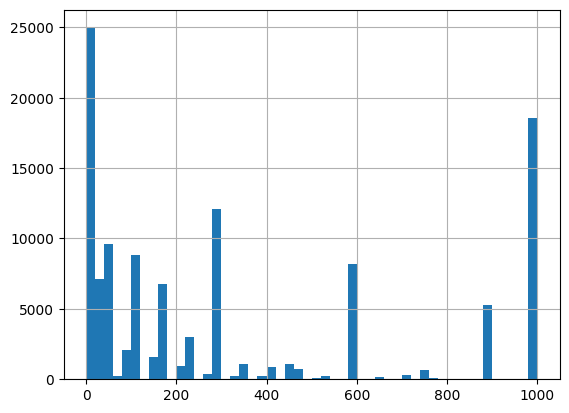

In [92]:
parsed_df["duration_seconds"].clip(upper=1000).hist(bins=50)

#### B. Sightings Over Time

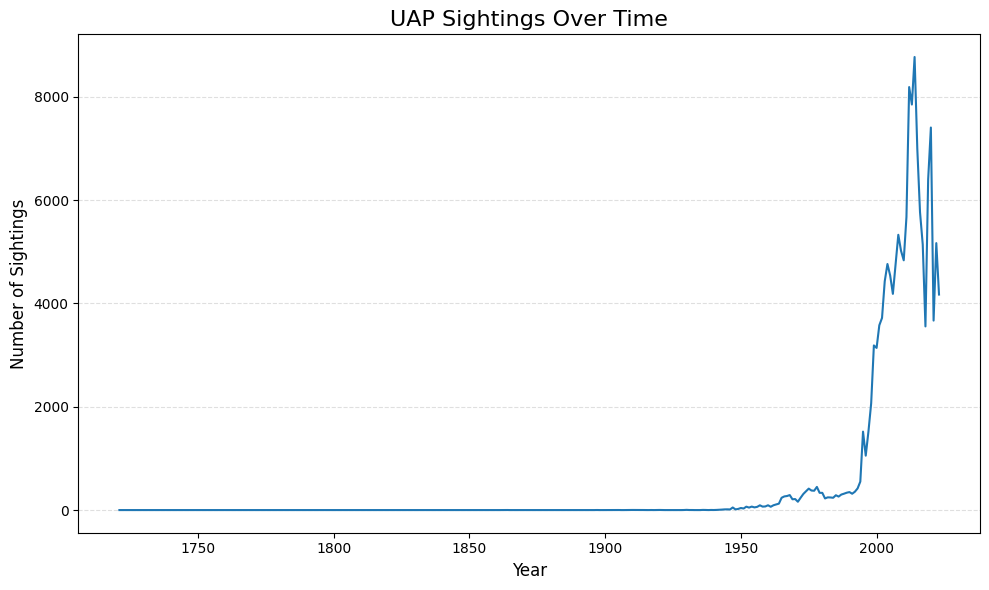

In [93]:
import matplotlib.pyplot as plt

# Count sightings per year
year_counts = parsed_df["year"].value_counts().sort_index()

plt.figure(figsize=(10,6))

year_counts.plot()

plt.title("UAP Sightings Over Time", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Sightings", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

plt.show()

In [94]:
# Identify earliest and latest sightings
min_date = parsed_df["observation_date"].min()
max_date = parsed_df["observation_date"].max()

min_date, max_date

(Timestamp('1721-02-01 05:24:00'), Timestamp('2023-12-20 05:30:00'))

#### C. Sightings by State

<Axes: xlabel='state'>

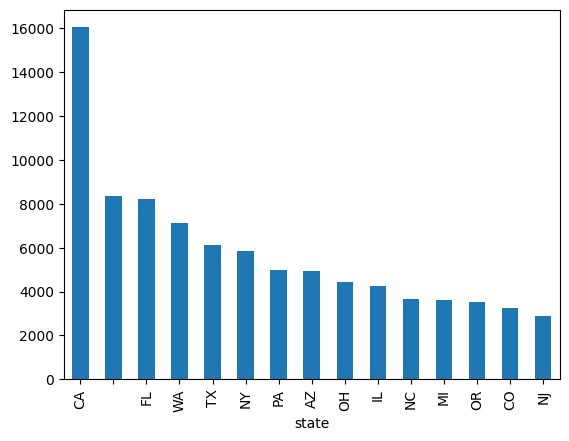

In [95]:
parsed_df["state"].value_counts().head(15).plot(kind="bar")

**Interpretation**
- understand the baseliine patterns

#### Spatial Analysis

#### A. Heatmap/ counts by location

In [96]:
# sightings per city, state, country
# latitude/longitude scatter

#### B. Urban vs rual (if possible)

**Note**: This direclty maps to: spatial heatmaps

### 12.5 Duration Anomolies by Location

- Where are long sightings happening?
- What's "normal" vs "extreme"?

In [97]:
df.groupby("state")["duration_seconds"].mean()

NameError: name 'df' is not defined

**Interpretation**
- this maps to duration anaomolies

### 12.6 Temporal Trends 

- Are sightings increasing over time? (especially from the earliest point of the data to the latest point in the data)?
- Are there spikes?
- Is there data from around the world or only the USA?

In [ ]:
# comment on spikes increasing over time (but over time where? in USA, around the world?)
df.groupby("year").size().splot()

SyntaxError: invalid syntax (2247748558.py, line 3)

**Interpretation**:
 this maps to temporal-spatial events

### 12.7 Shape + Location Correlation

In [ ]:
pd.crosstab(df["state"], df["final_shape"])

NameError: name 'df' is not defined

In [ ]:
df.groupby(["state", "final_shape"]).size().unstack().fillna(0)

**Interpretation**
- I am expecting a stacked bar chart with top shapes by city/state/region/country as visuals

Markdown should explain:
- patterns, clusters, anomolies 

### 12.8 Outlier Detection

- identify extreme durations
- weird locations
- inconsistent records

In [ ]:
df[df["duration_seconds"] > df["durastion_seconds"].quantile(0.99)]

NameError: name 'df' is not defined

**Interpretation**
- this maps to outlier detection 